<a href="https://colab.research.google.com/github/Tookss55/DS/blob/main/Unit8/Amir_RegaUnit8Proj.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Unit 8 Project: Predicting County Life Expectancy with BART

## Part I: Introduction

For my Unit 8 project, I will use BART to model county life expectancy across the United States. Life expectancy is one of the most important summary statistics for population health. It shows how social, economic, and behavioral conditions translate into actual years lived. I hope to understand which factors best predict life expectancy at the county level, and to see whether there are meaningful interactions between those predictors.

The five predictors I will use are:

1. Poverty Rate — the percentage of county residents living below the poverty line
2. % Smokers — the percentage of adults who currently smoke
3. % Adults with Obesity — the percentage of adults classified as obese
4. Average Income — the average household income in the county
5. % with Bachelor's Degree or Higher** — an indicator of educational attainment

## Part II: Setup and Libraries

In [ ]:
!pip install pymc-bart

In [6]:
import arviz as az
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pymc as pm
import pymc_bart as pmb
import seaborn as sns
import graphviz as gr

## Part III: Data

The dataset contains 3,142 U.S. counties with a wide range of demographic, economic, health, and environmental variables. We will load it directly and only use the variables relevant to our model. After dropping rows with any missing values in our selected columns, we are left with 3,140 counties.

My target variable is life expectancy, measured in years. Our five predictors are poverty rate, smoking rate, obesity rate, average income, and bachelor's degree attainment rate.

**Upload the dataset:** Run the cell below and upload the `UNIT8_Proj_Data.csv` file when prompted.

In [7]:
#import data and choose variables
county_data = pd.read_csv("https://raw.githubusercontent.com/Tookss55/DS/refs/heads/main/Unit8/UNIT8_Proj_Data.csv")

selected_cols = [
    'life-expectancy',
    'poverty-rate',
    'health/% Smokers',
    'health/% Adults with Obesity',
    'avg_income',
    'edu/bachelors+'
]

df = county_data[selected_cols].dropna().copy()

# rename columns to make them easier to read and work with
df.columns = ['life_expectancy', 'poverty_rate', 'pct_smokers',
              'pct_obese', 'avg_income', 'pct_bachelors']

df.head(5)

,life_expectancy,poverty_rate,pct_smokers,pct_obese,avg_income,pct_bachelors
0,81.20,8.9,16.269774,39.2,58610,23.8
1,80.46,10.7,16.430798,29.8,49889,39.5
2,80.12,11.2,18.229344,35.3,50836,20.9
3,79.24,11.1,18.297152,32.4,45896,20.5
4,79.86,10.0,16.168955,37.8,52792,23.5


In [8]:
# calculate means
print("Mean Life Expectancy:     ", round(df.life_expectancy.mean(), 2), "years")
print("Mean Poverty Rate:        ", round(df.poverty_rate.mean(), 2), "%")
print("Mean % Smokers:           ", round(df.pct_smokers.mean(), 2), "%")
print("Mean % Obese:             ", round(df.pct_obese.mean(), 2), "%")
print("Mean Average Income:      $", round(df.avg_income.mean(), 2))
print("Mean % Bachelor's+:       ", round(df.pct_bachelors.mean(), 2), "%")

Mean Life Expectancy:      77.75 years
Mean Poverty Rate:         14.46 %
Mean % Smokers:            21.33 %
Mean % Obese:              33.46 %
Mean Average Income:      $ 44174.76
Mean % Bachelor's+:        21.96 %


The average county-level life expectancy in the U.S. is approximately 77.75 years. The large variation in income, education, smoking, and obesity rates across counties gives us a good range of predictor values to work with.

## Part IV: Variable Selection & Justification

#### Theoretical Justification:

- Poverty Rate: Poverty is one of the most well established social determinants of health. Counties with higher poverty have reduced access to healthcare, healthier food, safe housing, and welfare services, all of which directly shorten life.
- % Smokers: Smoking is the leading cause of preventable death in the United States. It causes lung cancer, heart disease, stroke, and COPD. A county with more smokers should have lower life expectancy.
- % Obese: Obesity is strongly associated with diabetes, cardiovascular disease, and different types of cancers. Like smoking, it is a direct behavioral risk factor that shortens life expectancy.
- Average Income: Higher income enables access to better healthcare, healthier diets, safer neighborhoods, and lower chronic stress. It is both a direct determinant and a mediator of many other health outcomes.
- % Bachelor's Degree or Higher**: Education is a powerful predictor of health literacy, income, occupation, and health behavior. More educated populations tend to have lower smoking rates, better preventive care usage, and longer lives.

Also, the pair plot below confirms that all five predictors have a meaningful relationship with life expectancy.

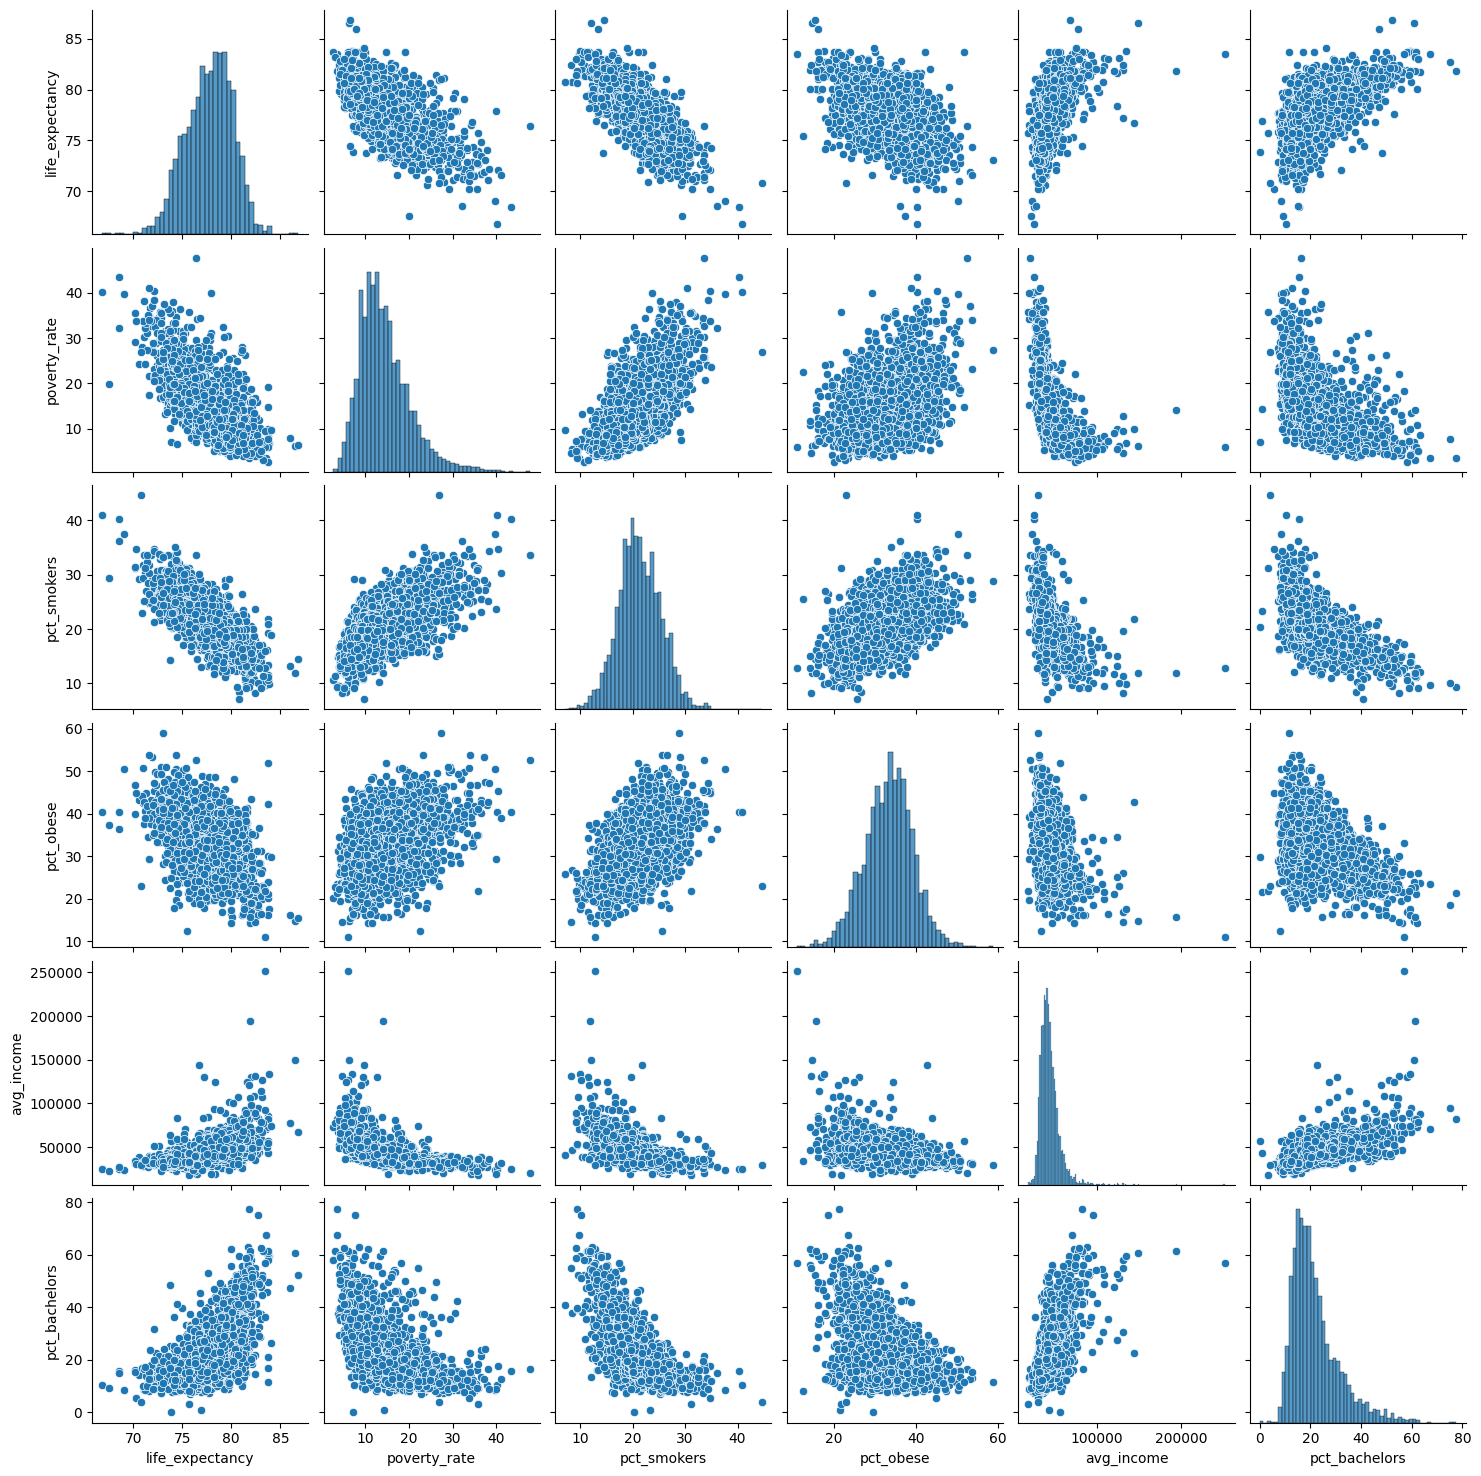

In [9]:
sns.pairplot(df)

## Part V: Causal Diagram

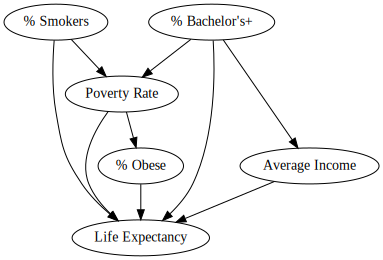

In [10]:
dot = gr.Digraph(format='png')

# Outcome
dot.node("LE", "Life Expectancy")

#predictors
dot.node("POV", "Poverty Rate")
dot.node("SMK", "% Smokers")
dot.node("OBS", "% Obese")
dot.node("INC", "Average Income")
dot.node("EDU", "% Bachelor's+")


# predictors to outocome
dot.edge("POV", "LE")
dot.edge("SMK", "LE")
dot.edge("OBS", "LE")
dot.edge("INC", "LE")
dot.edge("EDU", "LE")


# interactions among predictors
dot.edge("SMK", "POV")
dot.edge("POV", "OBS")
dot.edge("EDU", "INC")
dot.edge("EDU", "POV")

dot

The causal diagram above illustrates how our five predictors connect to life expectancy, and importantly, how they connect **to each other**. Geography and regional culture shape income, education, poverty, and behavioral norms like smoking. Education feeds into income, income shapes access to healthcare and food, and poverty amplifies both smoking and obesity rates. This web of interactions is exactly what makes BART — which can capture non-linear relationships and implicit interactions — superior to a simple linear regression for this problem.

## Part VI: BART Model — All Five Predictors

In [11]:
# Prepare X and Y
X = df[['poverty_rate', 'pct_smokers', 'pct_obese', 'avg_income', 'pct_bachelors']]
Y = df['life_expectancy'].to_numpy()

In [ ]:
with pm.Model() as model_full:
    s = pm.HalfNormal('s', 10)
    mu = pmb.BART("mu", X, Y, m=50)
    y = pm.Normal("y", mu=mu, sigma=s, observed=Y)
    idata_full = pm.sample(compute_convergence_checks=False)

In [13]:
# R-squared for the full model
pmb.utils.plot_convergence(idata_full)
plt.show()

/usr/local/lib/python3.12/dist-packages/pymc_bart/utils.py:108: FutureWarning: This function has been deprecatedUse az.plot_convergence_dist() instead.https://arviz-plots.readthedocs.io/en/latest/api/generated/arviz_plots.plot_convergence_dist.html
  warnings.warn(


In [14]:
# Compute R-squared
r2_full = az.r2_score(Y, idata_full.posterior['mu'].values.reshape(-1, len(Y)))
print(f"Full Model R² = {r2_full['r2'].mean():.4f}")

Full Model R² = 0.6530


In [ ]:
pm.sample_posterior_predictive(idata_full,model_full, extend_inferencedata=True)

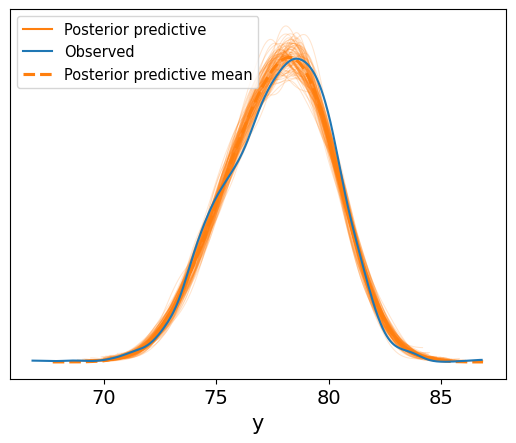

In [16]:
ax = az.plot_ppc(idata_full, num_pp_samples=100, colors=["C1", "C0", "C1"])

My Posterior preidctive check looks pretty perfect. The peaks almost match perfectly. Now to see which factors influence the model the most, I will create VI, PD, and ICE plots.

## Part VII: Variable Importance and PDP/ICE Plots

<Axes: ylabel='R²'>

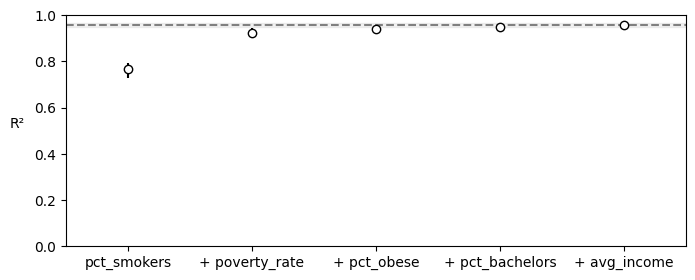

In [17]:
vi_full = pmb.compute_variable_importance(idata_full, model_full["mu"], X, model=model_full)
pmb.plot_variable_importance(vi_full)

It's clear that the most important factor is pct_smokers, and the least important factor is pct_bachelors. This makes a lot of sense because smoking would have the largest consequence on physical health, and it's very possible to be successful in life without a college degree. Now I'm going to make a PD plot then ICE plot.

array([<Axes: xlabel='poverty_rate'>, <Axes: xlabel='pct_smokers'>,
       <Axes: xlabel='pct_obese'>, <Axes: xlabel='avg_income'>,
       <Axes: xlabel='pct_bachelors'>], dtype=object)

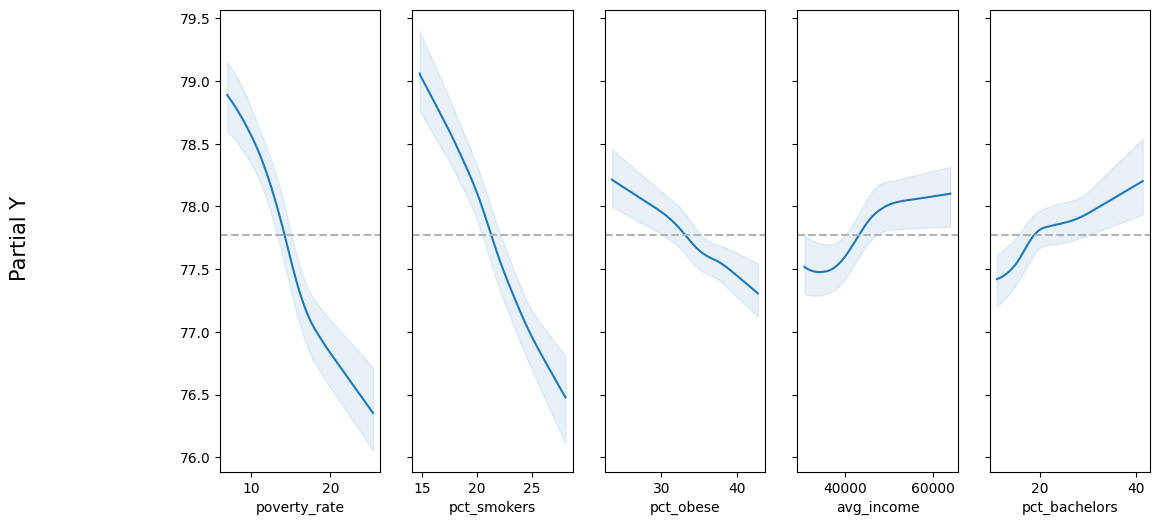

In [18]:
pmb.plot_pdp(model_full["mu"], X, Y, grid=(1, 5), figsize = (12,6))

array([<Axes: xlabel='poverty_rate'>, <Axes: xlabel='pct_smokers'>,
       <Axes: xlabel='pct_obese'>, <Axes: xlabel='avg_income'>,
       <Axes: xlabel='pct_bachelors'>], dtype=object)

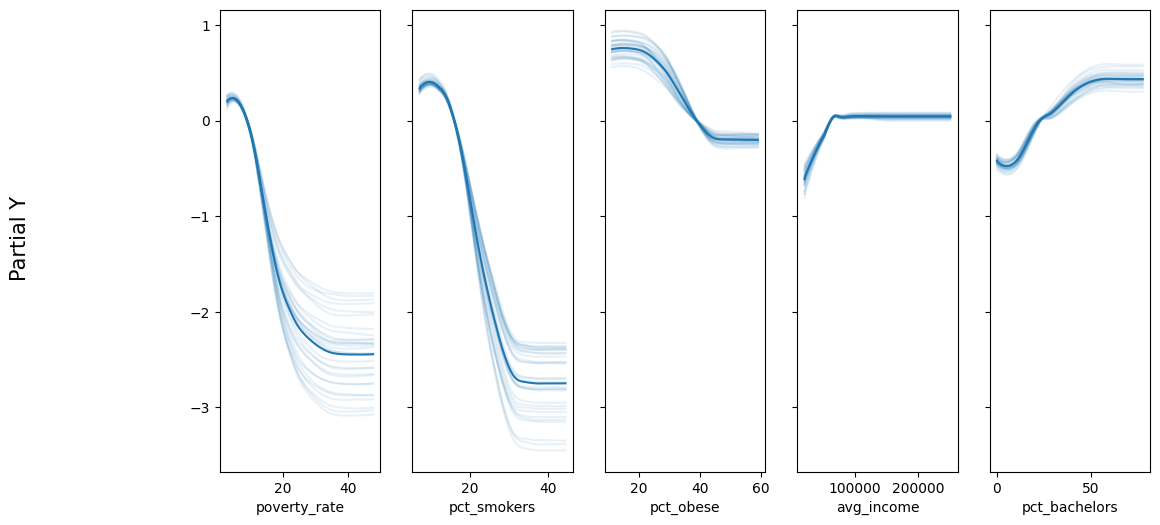

In [19]:
pmb.plot_ice(model_full["mu"], X, Y, grid=(1, 5), figsize = (12,6))

The PD plot show the average marginal effect of each predictor on life expectancy, holding all other variables constant. Considering that we see positive slopes for poverty rate, % smokers, and % obese and negative slopes for average income and % bachelor's, we know that poverty rate, % smokers and % obese are the most representative of life expectancy.

The Ice curves reveal interactions. The ICE lines that are tightly bundled around the PDP are variable that behaves largely independently, such as avg_income and pct_bachelors. The lines fan out or cross are significant interactions with other predictors.

## Part VIII: Dropping Weakest Predictor to make Reduced BART Model

Based on the variable importance plot above, we identify the least important predictor is pct_bachelors and refit the model without it. This allows us to check whether that variable meaningfully contributed to model fit, or whether the simpler 4-variable model performs just as well.

In [20]:
# Drop the least important predictor (adjust column name if needed based on VI plot)
X_reduced = df[['poverty_rate', 'pct_smokers', 'pct_obese', 'avg_income']]
Y_reduced = df['life_expectancy'].to_numpy()

In [ ]:
with pm.Model() as model_reduced:
    s_r = pm.HalfNormal('s', 10)
    mu_r = pmb.BART("mu", X_reduced, Y_reduced, m=50)
    y_r = pm.Normal("y", mu=mu_r, sigma=s_r, observed=Y_reduced)
    idata_reduced = pm.sample(compute_convergence_checks=False)

In [22]:
# R-squared for the reduced model
r2_reduced = az.r2_score(Y_reduced, idata_reduced.posterior['mu'].values.reshape(-1, len(Y_reduced)))
print(f"Full Model R²    = {r2_full['r2'].mean():.4f}")
print(f"Reduced Model R² = {r2_reduced['r2'].mean():.4f}")

Full Model R²    = 0.6530
Reduced Model R² = 0.6503


In [ ]:
pm.sample_posterior_predictive(idata_reduced,model_reduced, extend_inferencedata=True)

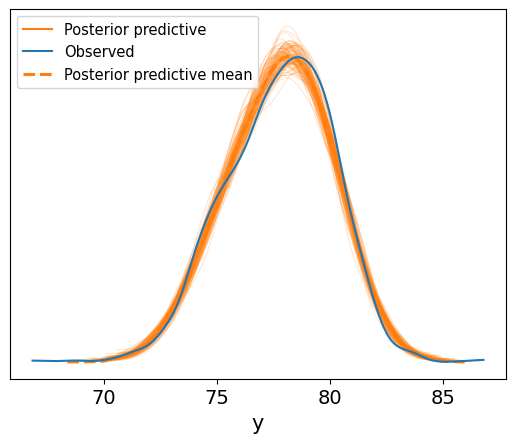

In [24]:
ax = az.plot_ppc(idata_reduced, num_pp_samples=100, colors=["C1", "C0", "C1"])

This posterior predictive check does look ever so slightly better than the last, with a peak that matches slightly better. Now I'll create VI, PD, and ICE plots for the new reduced bart model to see if the reduced model is actually a better model.

<Axes: ylabel='R²'>

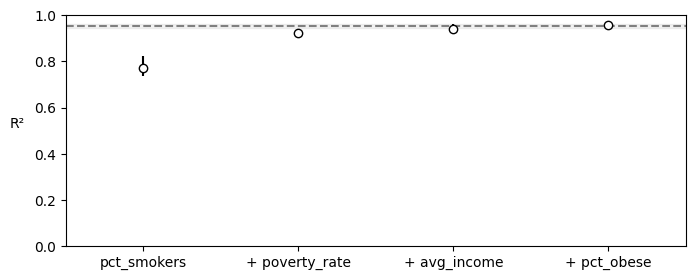

In [25]:
vi_reduced = pmb.compute_variable_importance(idata_reduced, model_reduced["mu"], X, model=model_reduced)
pmb.plot_variable_importance(vi_reduced)

array([<Axes: xlabel='poverty_rate'>, <Axes: xlabel='pct_smokers'>,
       <Axes: xlabel='pct_obese'>, <Axes: xlabel='avg_income'>,
       <Axes: xlabel='pct_bachelors'>], dtype=object)

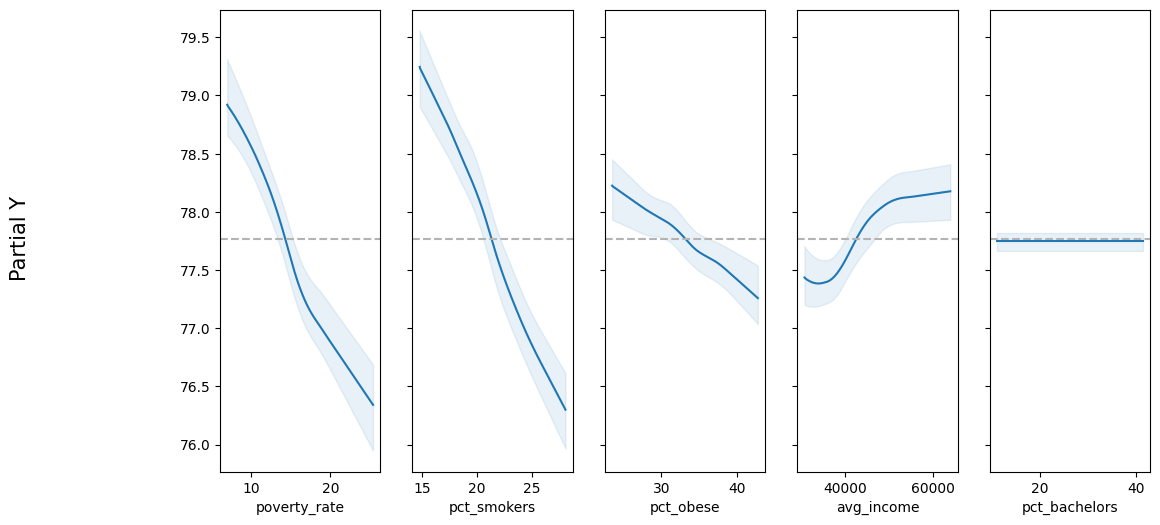

In [26]:
pmb.plot_pdp(model_reduced["mu"], X, Y, grid=(1, 5), figsize = (12,6))

array([<Axes: xlabel='poverty_rate'>, <Axes: xlabel='pct_smokers'>,
       <Axes: xlabel='pct_obese'>, <Axes: xlabel='avg_income'>,
       <Axes: xlabel='pct_bachelors'>], dtype=object)

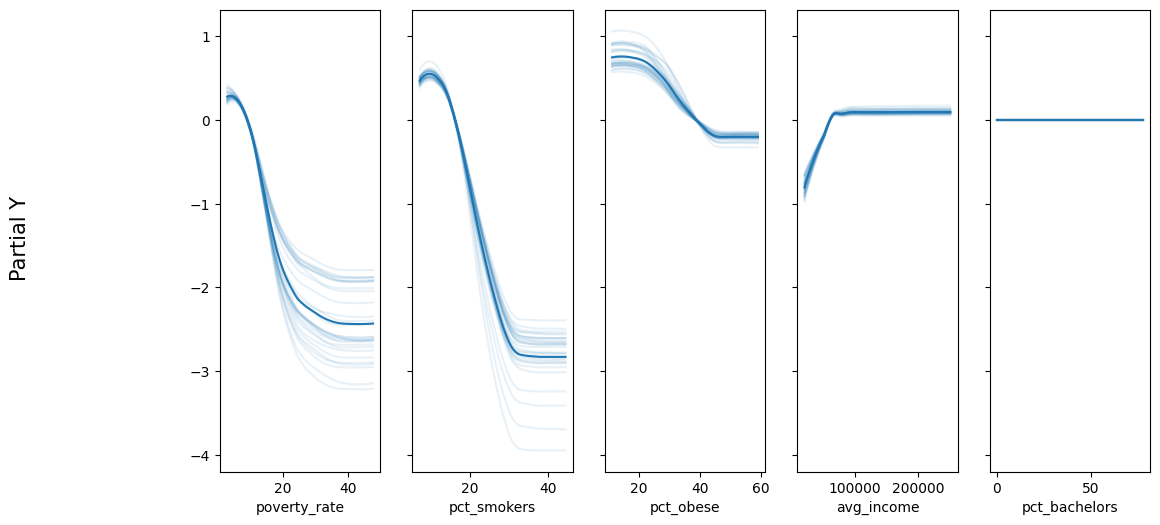

In [27]:
pmb.plot_ice(model_reduced["mu"], X, Y, grid=(1, 5), figsize = (12,6))

In [28]:
#Credit to Yale for helping me with this code
posterior_mean = idata_reduced.posterior["mu"]

μ_hdi = az.hdi(ary=idata_reduced, group="posterior", var_names=["mu"], hdi_prob=0.74)

pps = az.extract(
    idata_reduced, group="posterior_predictive", var_names=["y"]
).T

/usr/local/lib/python3.12/dist-packages/arviz/plots/hdiplot.py:166: FutureWarning: hdi currently interprets 2d data as (draw, shape) but this will change in a future release to (chain, draw) for coherence with other functions
  hdi_data = hdi(y, hdi_prob=hdi_prob, circular=circular, multimodal=False, **hdi_kwargs)
/usr/local/lib/python3.12/dist-packages/arviz/plots/hdiplot.py:166: FutureWarning: hdi currently interprets 2d data as (draw, shape) but this will change in a future release to (chain, draw) for coherence with other functions
  hdi_data = hdi(y, hdi_prob=hdi_prob, circular=circular, multimodal=False, **hdi_kwargs)


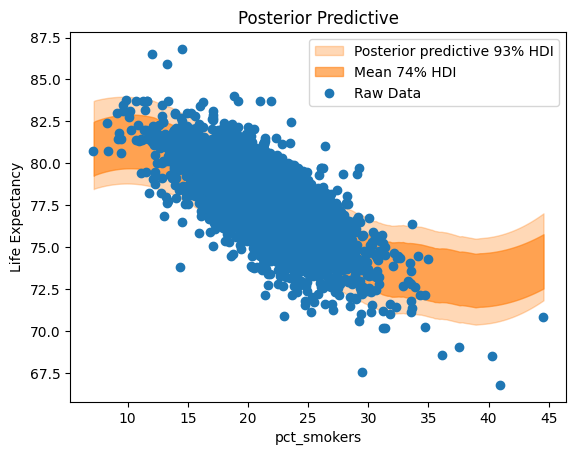

In [29]:
#Credit to Yale for helping me with this code
x_predictor = X_reduced['pct_smokers'].to_numpy()
idx = np.argsort(x_predictor)
x_sorted = x_predictor[idx]
pps_sorted = pps[:, idx]

fig, ax = plt.subplots()

az.plot_hdi(
    x=x_sorted,
    y=pps_sorted,
    ax=ax,
    hdi_prob=0.93,
    fill_kwargs={"alpha": 0.3, "label": r"Posterior predictive 93% HDI"},
)

az.plot_hdi(
    x=x_sorted,
    y=pps_sorted,
    ax=ax,
    hdi_prob=0.74,
    fill_kwargs={"alpha": 0.6, "label": r"Mean 74% HDI"},
)
# Plot raw data (pct_smokers vs life_expectancy)
ax.plot(df['pct_smokers'], df["life_expectancy"], "o", c="C0", label="Raw Data")
ax.legend(loc="upper right")
ax.set(
    title="Posterior Predictive",
    xlabel="pct_smokers",
    ylabel="Life Expectancy",
);

## Part IX: Conclusions

My Unit 8 project used BART to model county life expectancy in the United States using five predictors: poverty rate, smoking prevalence, obesity prevalence, average income, and bachelor's degree attainment.

The VI plots show that smoking rate is the dominant predictor of county level life expectancy, which makes sense as far as my knowledge goes. Poverty rate, average income, and percent obesity are also large contributors. Bachelors degree attainment is the weakest of the five predictors, probably because much of its variation is already captured by poverty and income, and there are many succesful people without college degrees.

The reduced model had an R² almost identical to the full model, so the obesity rate is irrelavent once the other four predictors are included. This doesn't mean obesity is unimportant to health, but that obesity's variation is mostly explained by the other predictors already in the model.

There are clearly interactions between the predictors on the ICE plots. The  effect of smoking on life expectancy isn't uniform, its curves fan out significantly, meaning that the harm from high smoking rates is amplified in counties that also have high poverty and low income. These interactions are why a BART model is the best choice here. A linear regression would have forced inependent effects on each predictor, leaving out the interactions between the predictors of life expectancy.